# project report on resume selection

# Executive Summery

As new candidates applying to the same job role with or without relevent set of skills mentioned in the job discription, insted of going thrugh each and every one we can make a machine learning programme that will sort thoes resumes to the details mention...

# Table of Contains

# 1. data import
# 2. Methodology
# 3. Results
# 4. Conculation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS      #used to creat wordcloud, it's visual representaion of the text
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer # natural language toolkit
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize  # t break down text into individual word
import gensim  # modeling and documantation
from gensim.utils import simple_preprocess # basic text processing
from gensim.utils import simple_tokenize   # basic tokenization
from gensim.parsing.preprocessing import STOPWORDS
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
resume_df = pd.read_csv(r'D:\resume_data.csv', encoding= 'latin-1')
resume_df

,resume_id,class,resume_text
0,resume_1,not_flagged,\rCustomer Service Supervisor/Tier - Isabella ...
1,resume_2,not_flagged,\rEngineer / Scientist - IBM Microelectronics ...
2,resume_3,not_flagged,\rLTS Software Engineer Computational Lithogra...
3,resume_4,not_flagged,TUTOR\rWilliston VT - Email me on Indeed: ind...
4,resume_5,flagged,\rIndependent Consultant - Self-employed\rBurl...
...,...,...,...
120,resume_121,not_flagged,\rBrattleboro VT - Email me on Indeed: indeed....
121,resume_122,not_flagged,\rResearch and Teaching Assistant - University...
122,resume_123,not_flagged,\rMedical Coder - Highly Skilled - Entry Level...
123,resume_124,flagged,\rWaterbury VT - Email me on Indeed: indeed.co...


In [5]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   resume_id    125 non-null    object
 1   class        125 non-null    object
 2   resume_text  125 non-null    object
dtypes: object(3)
memory usage: 3.1+ KB


In [6]:
resume_df['class'].value_counts()

class
not_flagged    92
flagged        33
Name: count, dtype: int64

In [7]:
resume_df['class'] = resume_df['class'].apply(lambda x:1 if x =='flagged' else 0)
resume_df

,resume_id,class,resume_text
0,resume_1,0,\rCustomer Service Supervisor/Tier - Isabella ...
1,resume_2,0,\rEngineer / Scientist - IBM Microelectronics ...
2,resume_3,0,\rLTS Software Engineer Computational Lithogra...
3,resume_4,0,TUTOR\rWilliston VT - Email me on Indeed: ind...
4,resume_5,1,\rIndependent Consultant - Self-employed\rBurl...
...,...,...,...
120,resume_121,0,\rBrattleboro VT - Email me on Indeed: indeed....
121,resume_122,0,\rResearch and Teaching Assistant - University...
122,resume_123,0,\rMedical Coder - Highly Skilled - Entry Level...
123,resume_124,1,\rWaterbury VT - Email me on Indeed: indeed.co...


In the dataframe "class" column transform categorical to binary format using lambda function

In [8]:
resume_df['resume_text'] == resume_df['resume_text'].apply(lambda x: x.replace('\r',''))


nltk.download('punkt') #Punkt tokenizer tokenizing text into sentences and words
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 'edu', 're', 'use', 'email', 'com'])
def precprocess(text):
    result =[]
    for token in gensim.utils.simple_preprocess(text):
        result.append(token)
    return ' '.join(result)    

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rupam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rupam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


tokenizing data into sentences and words and removing unnecessary charecters and filtering out common and repetitave words.

In [9]:
resume_df

,resume_id,class,resume_text
0,resume_1,0,\rCustomer Service Supervisor/Tier - Isabella ...
1,resume_2,0,\rEngineer / Scientist - IBM Microelectronics ...
2,resume_3,0,\rLTS Software Engineer Computational Lithogra...
3,resume_4,0,TUTOR\rWilliston VT - Email me on Indeed: ind...
4,resume_5,1,\rIndependent Consultant - Self-employed\rBurl...
...,...,...,...
120,resume_121,0,\rBrattleboro VT - Email me on Indeed: indeed....
121,resume_122,0,\rResearch and Teaching Assistant - University...
122,resume_123,0,\rMedical Coder - Highly Skilled - Entry Level...
123,resume_124,1,\rWaterbury VT - Email me on Indeed: indeed.co...


In [10]:
resume_df['cleaned'] = resume_df['resume_text'].apply(precprocess) # cleaning text data and moving clean data into new column

resume_df

,resume_id,class,resume_text,cleaned
0,resume_1,0,\rCustomer Service Supervisor/Tier - Isabella ...,customer service supervisor tier isabella cata...
1,resume_2,0,\rEngineer / Scientist - IBM Microelectronics ...,engineer scientist ibm division westford vt em...
2,resume_3,0,\rLTS Software Engineer Computational Lithogra...,lts software engineer computational lithograph...
3,resume_4,0,TUTOR\rWilliston VT - Email me on Indeed: ind...,tutor williston vt email me on indeed indeed c...
4,resume_5,1,\rIndependent Consultant - Self-employed\rBurl...,independent consultant self employed burlingto...
...,...,...,...,...
120,resume_121,0,\rBrattleboro VT - Email me on Indeed: indeed....,brattleboro vt email me on indeed indeed com b...
121,resume_122,0,\rResearch and Teaching Assistant - University...,research and teaching assistant university of ...
122,resume_123,0,\rMedical Coder - Highly Skilled - Entry Level...,medical coder highly skilled entry level sudbu...
123,resume_124,1,\rWaterbury VT - Email me on Indeed: indeed.co...,waterbury vt email me on indeed indeed com bec...


In [11]:
resume_df['cleaned'][0] # checking indivisual resume summery

'customer service supervisor tier isabella catalog company south burlington vt email me on indeed indeed com aecf work experience customer service supervisor tier isabella catalog company shelburne vt august to present customer service visual set up display website maintenance supervise customer service team of popular catalog company manage day to day issues and resolution of customer upset to ensure customer satisfaction troubleshoot order and shipping issues lost in transit order errors damages manage and resolve escalated customer calls to ensure customer satisfaction assist customers with order placing cross selling upselling of catalog merchandise set up and display of sample merchandise in catalog library as well as customer pick up area of the facility website clean up adding images type up product information proofreading administrative assistant events coordinator office services assistant eileen fisher inc irvington ny february to july support to director of architecture and

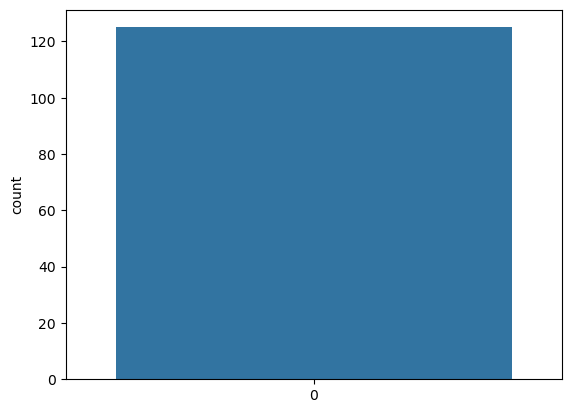

In [12]:
sns.countplot(resume_df['class'], label = 'Count Plot')
plt.show()

Dispalying the distribution of the classes in the "class" column of the dataframe .
Its provides a visual representation of the frequency of the each class.
It also helps to understand the distribution of the data and identify occurance of each unique values and  imbalance or patterns.

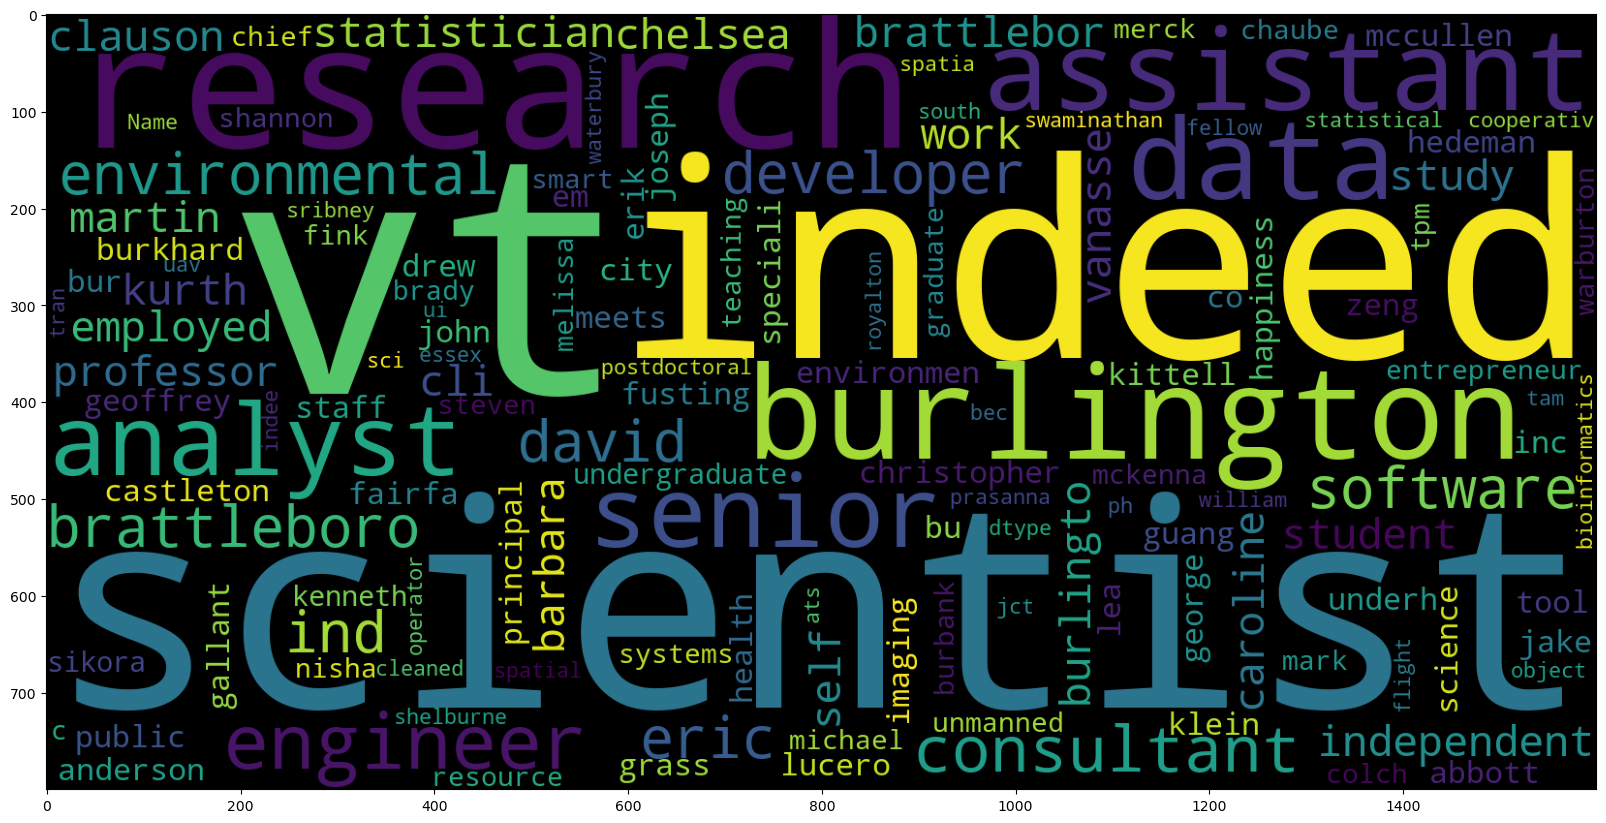

In [13]:
%matplotlib inline

plt.figure(figsize = (20, 20))

wc = WordCloud(max_words = 2000, width = 1600, height = 800, stopwords = stop_words).generate(str(resume_df[resume_df['class']==1].cleaned))

plt.imshow(wc)

The wordcloud visually representa the most frequent words in the from data set.
The size and apperence of each word in the word cloud are determined  by its frequency in  the text data.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
countvectorizer = vectorizer.fit_transform(resume_df['cleaned'])   # convert text data into a matrix of token counts

print(vectorizer.get_feature_names_out)

<bound method CountVectorizer.get_feature_names_out of CountVectorizer()>


In [15]:
print(countvectorizer.toarray())  # display matrix from of the text data 

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [16]:
X = countvectorizer
y = resume_df['class']

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)


from sklearn.naive_bayes import MultinomialNB

Bayes_clf = MultinomialNB(alpha = 3)
Bayes_clf.fit(X_train, y_train)  ## Training the model

MultinomialNB(alpha=3)

Preparing  data for machine learning task using Multinomia Naive Bayes calssifier.
Splitting dataset into training and testing set.
creating the classifer with specific hyperparameter and training the classifier on the training data.

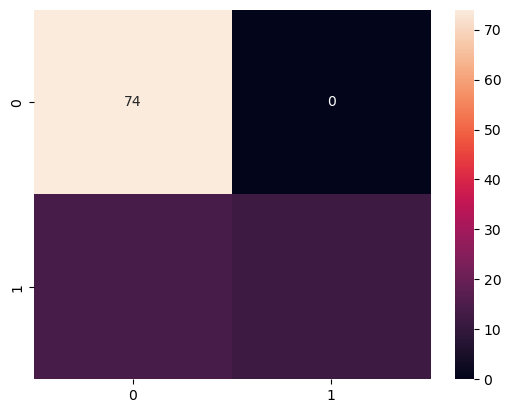

In [17]:
%matplotlib inline

# PLOTTING CONFUSION MATRIX:

# 1) FOR TRAINING DATA

y_pred_train = Bayes_clf.predict(X_train)

cm = confusion_matrix(y_train, y_pred_train)

sns.heatmap(cm, annot=True)

plt.show()

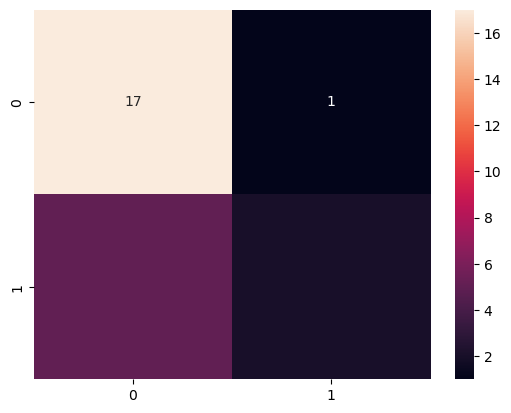

In [18]:
%matplotlib inline

# WE CAN SEE OUR MODEL PERFORMED REALLY WELL ON TRAINING DATA: IT CLASSFIED ALL OF THE POINTS CORRECTLY

# 2) FOR TEST DATA:

y_pred_test = Bayes_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True)

plt.show()

In [24]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        18
           1       0.67      0.29      0.40         7

    accuracy                           0.76        25
   macro avg       0.72      0.62      0.62        25
weighted avg       0.74      0.76      0.72        25



In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy of model on Train Dataset = {}".format(accuracy_score(y_train, y_pred_train)))
print("Accuracy of model on Test Dataset = {}".format(accuracy_score(y_test, y_pred_test)))

Accuracy of model on Train Dataset = 0.86
Accuracy of model on Test Dataset = 0.76


In [26]:
print("Accuracy of model is = {}".format(accuracy_score(y_test, y_pred_test)))
print("F1 of model is = {}".format(f1_score(y_test, y_pred_test)))
print("Precision of model is = {}".format(precision_score(y_test, y_pred_test)))
print("Recall of model is = {}".format(recall_score(y_test, y_pred_test)))

Accuracy of model is = 0.76
F1 of model is = 0.4
Precision of model is = 0.6666666666666666
Recall of model is = 0.2857142857142857


# Results

Accuracy of model on Train Dataset is 86% this means that the model correctly predicted the target variable for approximately 88% of the instances in the training dataset.

The accuracy of the model is 76%. This means that the model correctly classified 76% of the instances in your test set.
While this is a decent accuracy rate, especially considering the complexity of text classification tasks,but there always room for improvement.

 F1 score of 0.4 suggests that your model is not performing optimally issues with the model's ability to correctly identify positive instances (precision) or its ability to retrieve all relevant positive instances (recall)

 
A precision of around 66.67% means that about two-thirds of the instances of the model predicts as positive are indeed positive. This is a relatively strong precision, suggesting that the model is doing well in minimizing false positives.

A recall of around 28.57% indicates that your model is not very effective at retrieving all the relevant positive instances.


# Conculation

Since the Naive Bayes classifier has a limited set of parameters focusing on data preprocessing and feature selection is crucial. We have to ensure that  text preprocessing steps are effectively reducing noices, and we may have to add more features to improve models performence.
# naive bayes classifier
                        is a solid foundation  for text classification tasks but we have to experiment with various strategies for optimizeing its performence.
but as the results are quite decent we can trust the model to handle large dataset it could be trusted to process large volumes of data to reduce workload. However, this should be done under the supervision of an expert who can monitor the model's performance and make adjustments as needed.                       
 